# Cross-validation analysis (advanced)

In the [previous example](tutorial_1.ipynb), we used a single length scale parameter. However, this should be changed depending on whta your data is; if the intrinsic spatial resolution of the data is high, a smaller length scale is needed to reproduce smaller structures. To do this, the cross-validation analysis is useful.

## 1. Import modules and data

As we introduced in the previous section, we first import modules and data

In [1]:
import frap
import numpyro
import pickle
import dsharp_opac
import jax.numpy as jnp

numpyro.set_host_device_count(10)

bands = [ 'band3', 'band6' ]
data = {
    'band3' : 'HD169142_band3.pkl',
    'band6' : 'HD169142_band6.pkl'
}

obs = {}

for band in bands:
    with open(data[band], 'rb') as f:
        obs[band] = pickle.load(f)
        

In this example, we try a five-fold cross validation. We randomly split the dataset to 5 subsets.

In [2]:
n_folds = 5
train_obs, test_obs = frap.cv.split_data(n_folds, bands, obs)

You can see the splitted data like this. Here, 5 sets are plotted with offsets. The blue dots are the training data sets and oranges are the test datasets. The model will be fitted to the blue ones first, and the chi-squared of the best-fit model will be measured against the orange data. This procedure will be iterated for the 5 sets, and the mean chi-squared and its standared deviation will be calcurated.

Text(0, 0.5, 'amplitude')

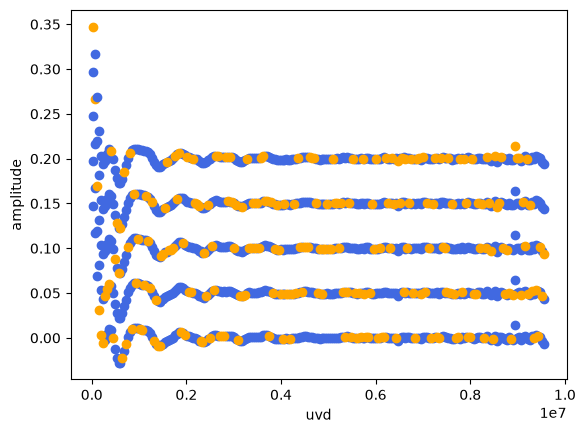

In [3]:
import matplotlib.pyplot as plt

band = 'band6'

offset = 0

for fold_id in range(n_folds):
    
    plt.scatter( train_obs[fold_id][band]['q'][0], train_obs[fold_id][band]['V'][0] + offset, color='royalblue'  )
    plt.scatter( test_obs[fold_id][band]['q'][0], test_obs[fold_id][band]['V'][0]+ offset, color='orange'  )
    
    offset += 0.05

plt.xlabel('uvd')
plt.ylabel('amplitude')

We construct the model in the same way as before. However, we make a function this time as we are going to iteretively run it.

In [4]:
dust_opacity = jnp.load(dsharp_opac.get_datafile('default_opacities_smooth.npz'))



def set_model( obs, lengthscale ):
    
    disk = frap.model( incl= 6.28,
                         r_out = 1.3,
                         N_GP = 260, # smaller
                         flux_uncert = True )
    
    
    D = 114.9 # pc
    
    disk.set_parameter('log10_T',
                       free = False,
                       profile = lambda r: jnp.log10(77.0*(r*D/10)**(-0.5)) )
    
    
    disk.set_parameter('q',
                       free = False,
                       profile = lambda r: 3.5 )
    
    
    
    
    disk.set_parameter('log10_Sigma_d', free = True,
                                        bounds = ( -6.0, 3.0 ),
                                        lengthscale = lengthscale)
    
    disk.set_parameter('log10_a_max', free = True,
                                        bounds =  ( -2.0, 2.0 ),
                                        lengthscale = lengthscale)
    
    
    f_s = { 'band3': 0.025, 'band6': 0.05 }
    f_mean = { 'band3': 1.0, 'band6': 1.0 }
    
    for band in bands:
        disk.set_visibility( band = band,
                                q = obs[band]['q'],
                                V = obs[band]['V'],
                                s = obs[band]['s'],
                                nu = obs[band]['nu'],
                                Nch = obs[band]['Nch'],
                                f_s = f_s[band],
                                f_mean = f_mean[band] )
    
    
    disk.set_opacity( opac_dict = dust_opacity )

    return disk
    


This is the core part of this experiment. We vary the length scale parameter from 0.01 to 0.2 arcsec with 6 steps. We fit the model to the training datasets using the Stochastic Variational Inference (SVI). Note that this aims to just get the MAP estimate rather than the posterior probability distribution. The best-fit model (contained in `map_estimate`) is then passed to ``calc_chi2()`` and calcurated the chi-squared between the test data and trained model.

In [5]:
import numpy as np

In [6]:

lengthscales = np.logspace( np.log10(0.01), np.log10(0.2), 6 )
chi2_arr_dict = {}


for il, lengthscale in enumerate(lengthscales):

    chi2_arr_dict[il] = np.array([])


    for fold_id in range(n_folds):
    
    
        disk_train = set_model( train_obs[fold_id], lengthscale )

        disk_test = set_model( test_obs[fold_id], lengthscale )

        inference = frap.inference( disk_train )

        map_estimate = inference.SVI_MAP( num_iterations=10000, adam_lr=0.1, seed = 1)
        

        chi2 = disk_test.calc_chi2( map_estimate )
              
        chi2_arr_dict[il] = np.append( chi2_arr_dict[il], chi2 )
        
        

100%|█████████████| 10000/10000 [00:02<00:00, 3548.39it/s, init loss: 3364994.4475, avg. loss [9501-10000]: 74551.3865]


Here we plot the results. We can see that the chi-squared satuates at a length scale of ~0.03 arcsec, although there are some outliers. In principle, any length scales smaller than this value can reasonably fit the data.

Text(0, 0.5, 'chi2')

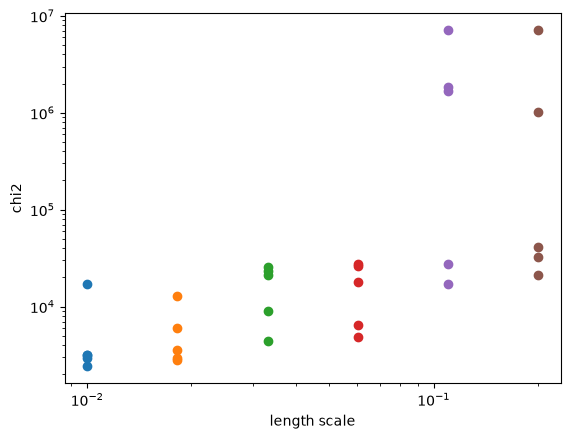

In [7]:
for il, lengthscale in enumerate(lengthscales):
    plt.scatter( [lengthscale]*n_folds,  chi2_arr_dict[il])

plt.yscale('log')
plt.xscale('log')
plt.xlabel('length scale')
plt.ylabel('chi2')